<a href="https://colab.research.google.com/github/Jun-0001/Calories-Burned-Prediction-ML/blob/main/%E1%84%86%E1%85%A5%E1%84%85%E1%85%B5%E1%84%8B%E1%85%A5%E1%84%81%E1%85%A28%E1%84%8C%E1%85%A9_%E1%84%8B%E1%85%A8%E1%84%8E%E1%85%B3%E1%86%A8%E1%84%86%E1%85%A9%E1%84%83%E1%85%A6%E1%86%AF%E1%84%86%E1%85%B5%E1%84%82%E1%85%B5%E1%84%91%E1%85%B3%E1%84%85%E1%85%A9%E1%84%8C%E1%85%A6%E1%86%A8%E1%84%90%E1%85%B3_%E1%84%8C%E1%85%A6%E1%84%8E%E1%85%AE%E1%86%AF_260223.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 📦 설치
# ============================================================
!pip install optuna catboost shap koreanize-matplotlib -q

# ============================================================
# 📚 라이브러리
# ============================================================
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from numpy.linalg import lstsq
from catboost import CatBoostRegressor
import optuna, warnings, shap
import koreanize_matplotlib  # 한글 폰트 자동 설정
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# 📂 데이터 로드 + 단위 변환
# ============================================================
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

for df in [train, test]:
    df['Height_cm']          = df['Height(Feet)']*30.48 + df['Height(Remainder_Inches)']*2.54
    df['Weight_kg']          = df['Weight(lb)'] * 0.453592
    df['Body_Temperature_C'] = (df['Body_Temperature(F)'] - 32) * 5/9
    df.drop(columns=['Height(Feet)','Height(Remainder_Inches)',
                     'Weight(lb)','Body_Temperature(F)'], inplace=True)

y      = train['Calories_Burned'].values
X      = train.drop(columns=['Calories_Burned','ID'])
X_test = test.drop(columns=['ID'])

assert X.isnull().sum().sum() == 0
assert (X['Exercise_Duration'] > 0).all()
print("✅ 데이터 검증 통과")

# ============================================================


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 51.8 MB/s eta 0:00:00
✅ 데이터 검증 통과


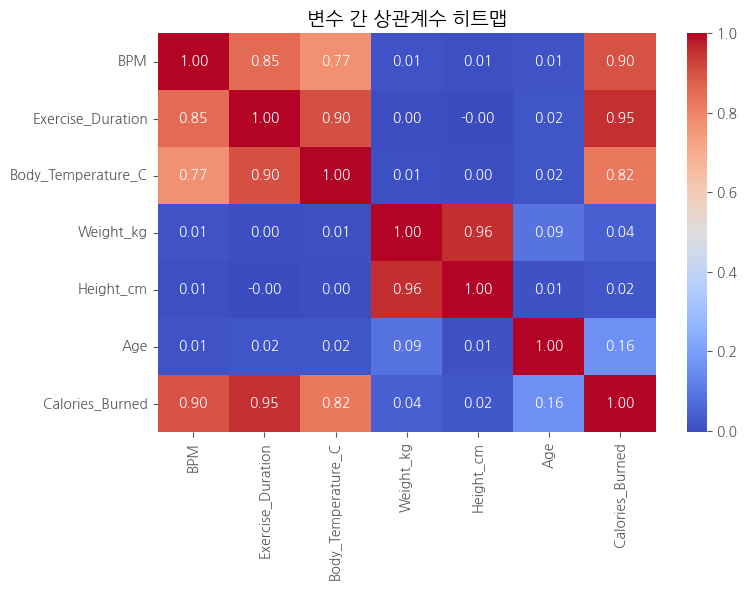

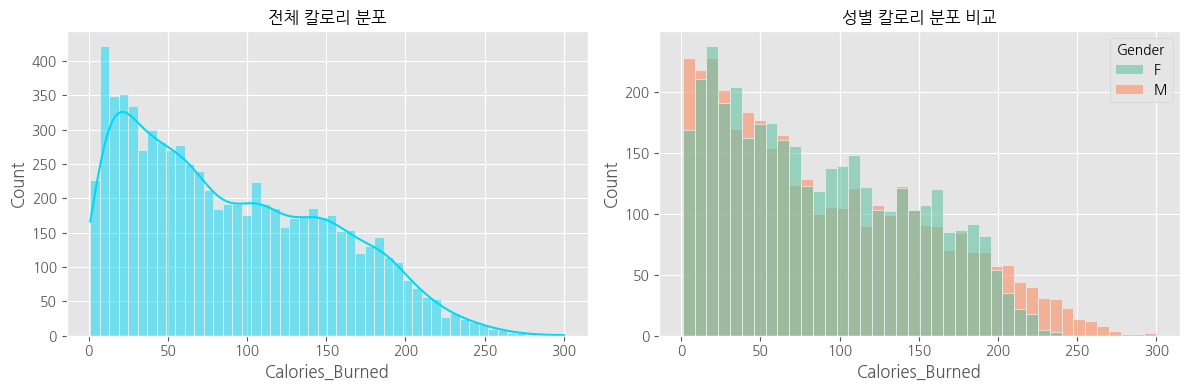

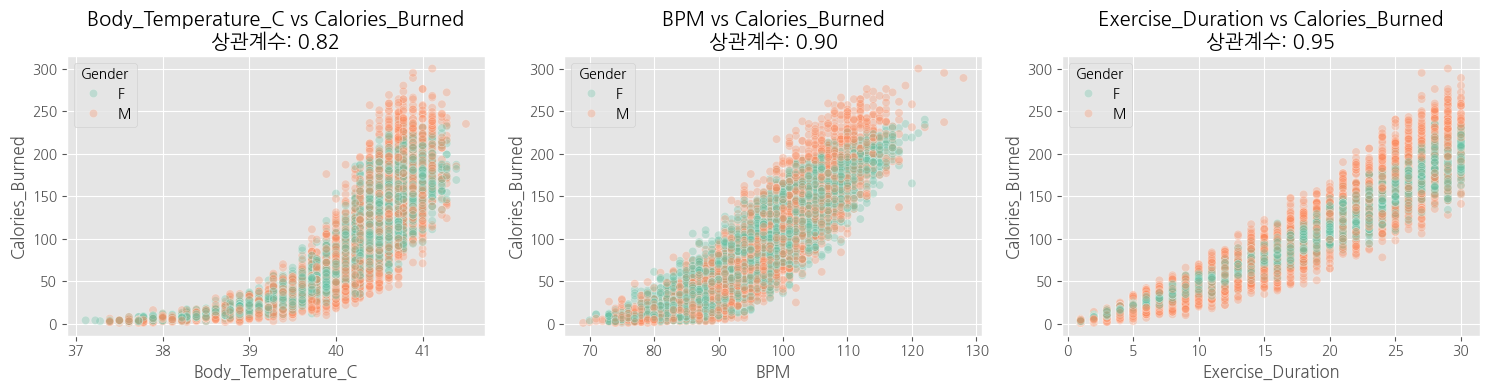

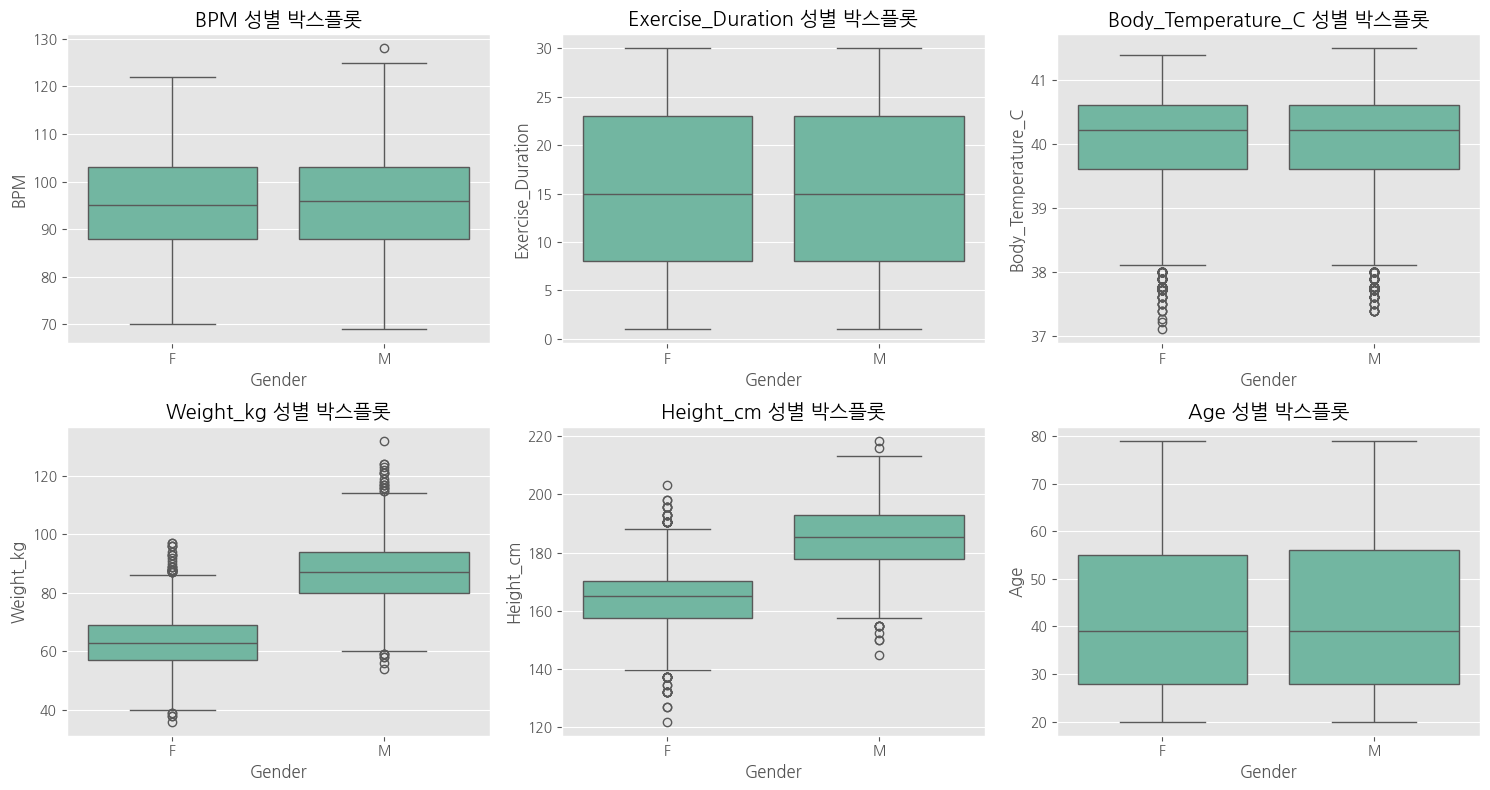

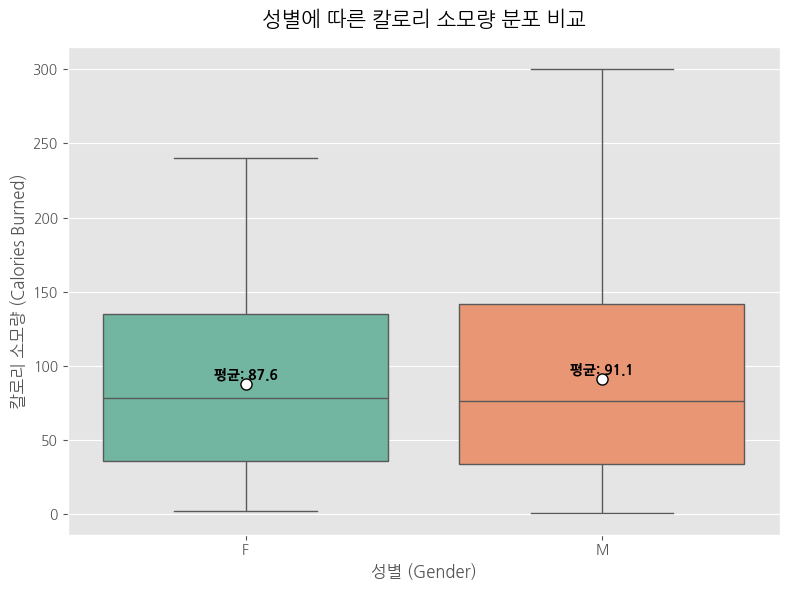

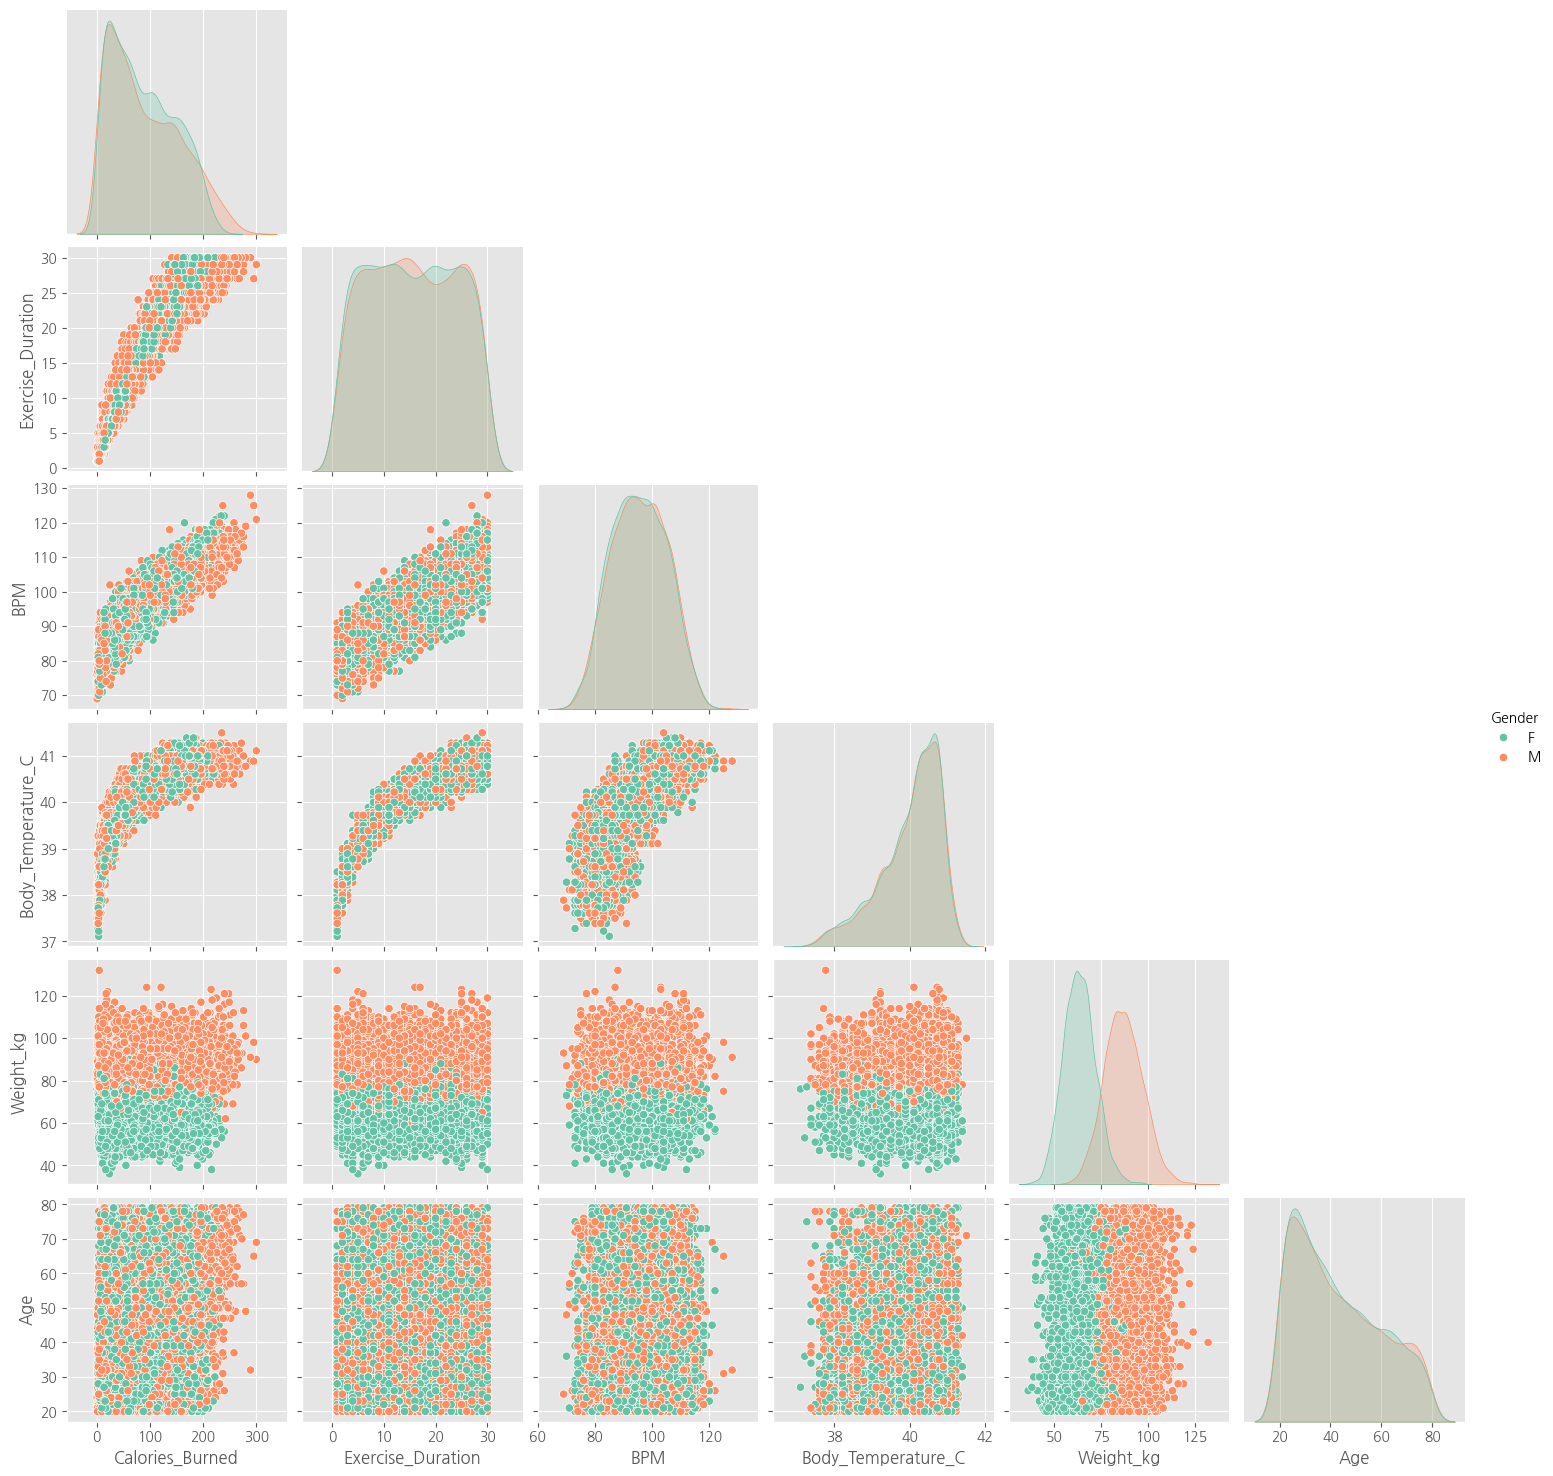

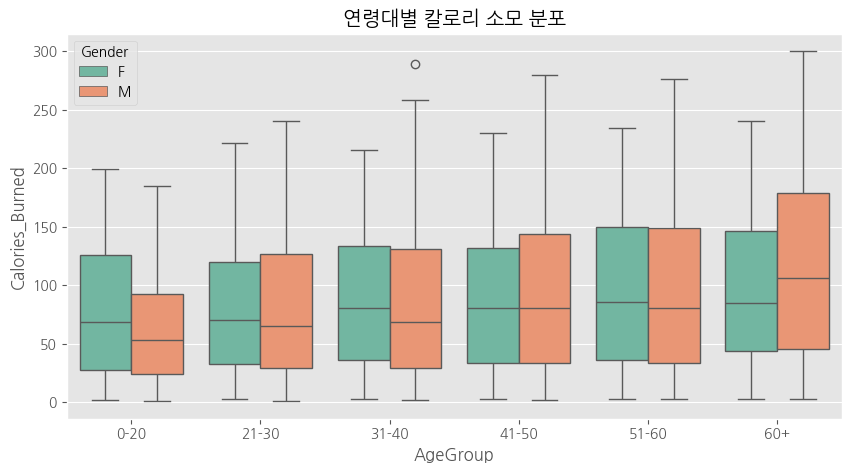

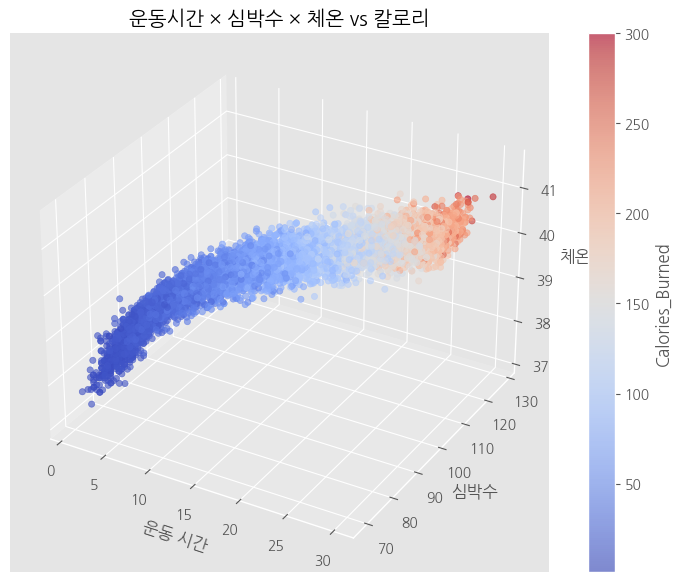

✅ 모든 EDA 그림 생성 완료! PPT에 바로 활용 가능


In [ ]:
# ── 필수 라이브러리 ────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
from scipy import stats
import warnings

plt.style.use('ggplot')
sns.set_palette('Set2')
warnings.filterwarnings('ignore')

# ── 데이터 로드 + 단위 변환 ─────────────────────────
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

for df in [train, test]:
    df['Height_cm']          = df['Height(Feet)']*30.48 + df['Height(Remainder_Inches)']*2.54
    df['Weight_kg']          = df['Weight(lb)'] * 0.453592
    df['Body_Temperature_C'] = (df['Body_Temperature(F)'] - 32) * 5/9
    df.drop(columns=['Height(Feet)','Height(Remainder_Inches)',
                     'Weight(lb)','Body_Temperature(F)'], inplace=True)

# ── 1. 상관계수 히트맵 ─────────────────────────────
num_cols = ['BPM', 'Exercise_Duration', 'Body_Temperature_C',
            'Weight_kg', 'Height_cm', 'Age', 'Calories_Burned']

corr = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax)
ax.set_title('변수 간 상관계수 히트맵', fontsize=14)
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150)
plt.show()

# ── 2. 칼로리 분포 + 성별 비교 ──────────────────────
fig, axes = plt.subplots(1,2,figsize=(12,4))

sns.histplot(train['Calories_Burned'], bins=50, kde=True, ax=axes[0], color='#00d9f5')
axes[0].set_title('전체 칼로리 분포', fontsize=12)

sns.histplot(data=train, x='Calories_Burned', hue='Gender', bins=40, alpha=0.6, ax=axes[1])
axes[1].set_title('성별 칼로리 분포 비교', fontsize=12)

plt.tight_layout()
plt.savefig('eda_calorie_dist.png', dpi=150)
plt.show()

# ── 3. 핵심 변수 vs 칼로리 산점도 ─────────────────
core_cols = ['Body_Temperature_C', 'BPM', 'Exercise_Duration']
fig, axes = plt.subplots(1,3,figsize=(15,4))

for ax, col in zip(axes, core_cols):
    sns.scatterplot(data=train, x=col, y='Calories_Burned', hue='Gender', alpha=0.3, ax=ax)
    ax.set_title(f'{col} vs Calories_Burned\n상관계수: {train[col].corr(train["Calories_Burned"]):.2f}')

plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150)
plt.show()

# ── 4. 이상치 탐지 (Boxplot) ───────────────────────
fig, axes = plt.subplots(2,3,figsize=(15,8))
for ax, col in zip(axes.flatten(), ['BPM','Exercise_Duration','Body_Temperature_C','Weight_kg','Height_cm','Age']):
    sns.boxplot(x='Gender', y=col, data=train, ax=ax)
    ax.set_title(f'{col} 성별 박스플롯')
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=150)
plt.show()

# 성별에 따른 칼로리 소모 분포 시각화
plt.figure(figsize=(8, 6))

# 1. Box-plot 생성 (평균값도 점으로 표시)
sns.boxplot(
    data=train,
    x='Gender',
    y='Calories_Burned',
    palette='Set2',
    showmeans=True, # 평균값을 별도로 표시
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# 2. 그래프 꾸미기
plt.title('성별에 따른 칼로리 소모량 분포 비교', fontsize=15, pad=15)
plt.xlabel('성별 (Gender)', fontsize=12)
plt.ylabel('칼로리 소모량 (Calories Burned)', fontsize=12)

# 3. 각 성별의 평균값 수치로 표시 (선택 사항)
means = train.groupby('Gender')['Calories_Burned'].mean()
for i, gender in enumerate(means.index):
    plt.text(i, means[gender] + 2, f'평균: {means[gender]:.1f}',
             ha='center', va='bottom', fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('eda_gender_calories_boxplot.png', dpi=150)
plt.show()

# ── 5. Pairplot (성별별 핵심 변수) ───────────────
subset = train[['Calories_Burned','Exercise_Duration','BPM','Body_Temperature_C','Weight_kg','Age','Gender']]
sns.pairplot(subset, hue='Gender', diag_kind='kde', corner=True)
plt.savefig('eda_pairplot.png', dpi=150)
plt.show()

# ── 6. 연령대별 칼로리 분포 ───────────────────────
train['AgeGroup'] = pd.cut(train['Age'], bins=[0,20,30,40,50,60,100],
                           labels=['0-20','21-30','31-40','41-50','51-60','60+'])
plt.figure(figsize=(10,5))
sns.boxplot(x='AgeGroup', y='Calories_Burned', hue='Gender', data=train)
plt.title('연령대별 칼로리 소모 분포')
plt.savefig('eda_agegroup.png', dpi=150)
plt.show()

# ── 7. 칼로리 소모 상호작용 예시 (운동시간 × 심박수 × 체온) ─
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(train['Exercise_Duration'], train['BPM'], train['Body_Temperature_C'],
               c=train['Calories_Burned'], cmap='coolwarm', alpha=0.6)
ax.set_xlabel('운동 시간')
ax.set_ylabel('심박수')
ax.set_zlabel('체온')
fig.colorbar(p, ax=ax, label='Calories_Burned')
plt.title('운동시간 × 심박수 × 체온 vs 칼로리')
plt.savefig('eda_3Dscatter.png', dpi=150)
plt.show()

print("✅ 모든 EDA 그림 생성 완료! PPT에 바로 활용 가능")

In [ ]:
# ⚙️ 피처 생성 (물리 기반 + 다항식)
# ============================================================
def build_base_features(df):
    D      = df['Exercise_Duration'].values
    BPM    = df['BPM'].values
    W      = df['Weight_kg'].values
    Age    = df['Age'].values
    T      = df['Body_Temperature_C'].values
    H      = df['Height_cm'].values
    Td     = T - 37.0
    mask_m = (df['Gender'] == 'M').values

    keytel = np.where(mask_m,
        (-55.0969 + 0.6309*BPM + 0.1988*W + 0.2017*Age) * D / 4.184,
        (-20.4022 + 0.4472*BPM - 0.1263*W + 0.074*Age)  * D / 4.184
    ).clip(0)

    bmr = np.where(mask_m,
        88.362  + 13.397*W + 4.799*H - 5.677*Age,
        447.593 +  9.247*W + 3.098*H - 4.330*Age
    )

    hr_ratio = BPM / np.maximum(220 - Age, 1)
    bsa      = np.sqrt(H * W / 3600)

    return np.column_stack([
        BPM*D, T*D, Td*D, W*D, Age*D, H*D, D, np.ones(len(df)),
        BPM*Td*D, BPM*W*D, Td*W*D, BPM*Age*D, Td*Age*D, H*W*D,
        BPM**2*D, Td**2*D, W**2*D,
        BPM*Td*W*D,
        keytel, keytel*Td, keytel*hr_ratio,
        bmr*D, bmr*hr_ratio*D,
        hr_ratio*D, hr_ratio*W*D, hr_ratio*Td*D,
        bsa*D, bsa*BPM*D,
    ])

# ============================================================
# ⚙️ Base 모델 학습
# ============================================================
def base_oof(tr_df, y, kf):
    oof = np.zeros(len(tr_df))
    for tr_idx, val_idx in kf.split(tr_df):
        for g in ['F', 'M']:
            tr_m  = (tr_df.iloc[tr_idx]['Gender'] == g).values
            val_m = (tr_df.iloc[val_idx]['Gender'] == g).values
            if tr_m.sum() == 0 or val_m.sum() == 0: continue
            c,_,_,_ = lstsq(build_base_features(tr_df.iloc[tr_idx][tr_m]),
                            y[tr_idx][tr_m], rcond=None)
            oof[val_idx[val_m]] = build_base_features(tr_df.iloc[val_idx][val_m]) @ c
    return oof

def base_full(tr_df, te_df, y):
    pred = np.zeros(len(te_df))
    for g in ['F', 'M']:
        tr_m = (tr_df['Gender'] == g).values
        te_m = (te_df['Gender'] == g).values
        c,_,_,_ = lstsq(build_base_features(tr_df[tr_m]), y[tr_m], rcond=None)
        pred[te_m] = build_base_features(te_df[te_m]) @ c
    return pred

print("📐 Base 모델 학습 중...")
kf10       = KFold(n_splits=10, shuffle=True, random_state=42)
train_base = base_oof(X, y, kf10)
test_base  = base_full(X, X_test, y)
base_rmse  = np.sqrt(mean_squared_error(y, train_base))
print(f"   기저 모델 OOF RMSE : {base_rmse:.6f}")

# ============================================================
# STEP 2: 잔차 + Box-Cox
# ============================================================
residual = y - train_base
if (residual <= 0).any():
    res_shift = float(1 - residual.min())
    res_bc, lambda_ = stats.boxcox(residual + res_shift)
else:
    res_shift = 0.0
    res_bc, lambda_ = stats.boxcox(residual)

def inv_bc(v, l):
    return np.exp(v) if l == 0 else np.power(np.maximum(v*l + 1, 1e-10), 1/l)

def raw_rmse(val_idx, oof_res):
    pred = np.clip(train_base[val_idx] + inv_bc(oof_res, lambda_) - res_shift, 1.0, None)
    return np.sqrt(mean_squared_error(y[val_idx], pred))

# ============================================================
# STEP 3: 피처 인코딩
# ============================================================
def encode_gbm(df, base_pred):
    d = df.copy()
    d['Gender'] = (d['Gender'] == 'M').astype(int)
    ws_map = {'Underweight':0,'Normal Weight':1,'Overweight':2,'Obese':3}
    d['Weight_Status'] = d['Weight_Status'].map(ws_map).fillna(1)
    d['Base'] = base_pred
    return d

def encode_cat(df, base_pred):
    d = df.copy()
    d['Base'] = base_pred
    return d

X_gbm    = encode_gbm(X,      train_base)
X_te_gbm = encode_gbm(X_test, test_base)
X_cat    = encode_cat(X,      train_base)
X_te_cat = encode_cat(X_test, test_base)

CAT_FEATURES = ['Gender', 'Weight_Status']

assert not X_gbm.isnull().any().any(), "❌ X_gbm NaN"
assert not X_cat.isnull().any().any(), "❌ X_cat NaN"
print("✅ 인코딩 검증 통과")

# ============================================================
# STEP 4-A: GBM Optuna (n_trials=100)
# ============================================================
kf_opt = KFold(n_splits=5, shuffle=True, random_state=42)

def gb_obj(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators', 300, 5000),
        learning_rate    = trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        max_depth        = trial.suggest_int('max_depth', 1, 4),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 80),
        max_features     = trial.suggest_float('max_features', 0.3, 1.0),
        random_state     = 42,
    )
    scores = []
    for tr, val in kf_opt.split(X_gbm):
        m = GradientBoostingRegressor(**p)
        m.fit(X_gbm.iloc[tr], res_bc[tr])
        scores.append(raw_rmse(val, m.predict(X_gbm.iloc[val])))
    return np.mean(scores)

print("\n🔍 [1/2] GBM Optuna (n_trials=100)...")
gb_study = optuna.create_study(direction='minimize')
gb_study.optimize(gb_obj, n_trials=100, show_progress_bar=True)
gb_best  = gb_study.best_params
print(f"✅ GBM 최적 RMSE : {gb_study.best_value:.6f}")

# ============================================================
# STEP 4-B: CatBoost Optuna (n_trials=50)
# ============================================================
def cat_obj(trial):
    p = dict(
        iterations        = trial.suggest_int('iterations', 500, 5000),
        learning_rate     = trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        depth             = trial.suggest_int('depth', 2, 6),
        l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        random_seed       = 42,
        verbose           = 0,
    )
    scores = []
    for tr, val in kf_opt.split(X_cat):
        m = CatBoostRegressor(**p, cat_features=CAT_FEATURES)
        m.fit(X_cat.iloc[tr], res_bc[tr],
              eval_set=(X_cat.iloc[val], res_bc[val]),
              early_stopping_rounds=100,
              verbose=0)
        scores.append(raw_rmse(val, m.predict(X_cat.iloc[val])))
    return np.mean(scores)

print("\n🔍 [2/2] CatBoost Optuna (n_trials=50)...")
cat_study = optuna.create_study(direction='minimize')
cat_study.optimize(cat_obj, n_trials=50, show_progress_bar=True)
cat_best  = cat_study.best_params
print(f"✅ CatBoost 최적 RMSE : {cat_study.best_value:.6f}")

# ============================================================
# STEP 4-C: 승자 결정
# ============================================================
print(f"\n{'='*45}")
print(f"  GBM      Optuna RMSE : {gb_study.best_value:.6f}")
print(f"  CatBoost Optuna RMSE : {cat_study.best_value:.6f}")

if gb_study.best_value <= cat_study.best_value:
    WINNER = 'GBM'
    print(f"  🏆 승자: GBM (차이: {cat_study.best_value - gb_study.best_value:+.6f})")
else:
    WINNER = 'CatBoost'
    print(f"  🏆 승자: CatBoost (차이: {gb_study.best_value - cat_study.best_value:+.6f})")
print(f"{'='*45}")

# ============================================================
# STEP 5: 최종 학습 (승자 모델 × 10-Fold × 10 Seeds)
# ============================================================
SEEDS = [42, 777, 2024, 1234, 99, 314, 5678, 9999, 111, 2077]
N     = 10
kf    = KFold(n_splits=N, shuffle=True, random_state=42)
oof_final  = np.zeros(len(y))
pred_final = np.zeros(len(test))
shap_model = None  # SHAP용 모델 저장 변수

print(f"\n=== 최종 학습: {WINNER} × 10-Fold × {len(SEEDS)} Seeds ===")

for seed in SEEDS:
    fold_oof = np.zeros(len(y))
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_gbm)):

        if WINNER == 'GBM':
            m = GradientBoostingRegressor(**{**gb_best, 'random_state': seed})
            m.fit(X_gbm.iloc[tr_idx], res_bc[tr_idx])
            fold_oof[val_idx]  = m.predict(X_gbm.iloc[val_idx])
            pred_final        += m.predict(X_te_gbm) / (len(SEEDS) * N)

            # SHAP용: 첫 번째 seed, 첫 번째 fold 모델만 저장
            if seed == 42 and fold == 0:
                shap_model = m

        else:  # CatBoost
            m = CatBoostRegressor(**{**cat_best,
                                     'random_seed': seed,
                                     'verbose': 0},
                                  cat_features=CAT_FEATURES)
            m.fit(X_cat.iloc[tr_idx], res_bc[tr_idx],
                  eval_set=(X_cat.iloc[val_idx], res_bc[val_idx]),
                  early_stopping_rounds=100,
                  verbose=0)
            fold_oof[val_idx]  = m.predict(X_cat.iloc[val_idx])
            pred_final        += m.predict(X_te_cat) / (len(SEEDS) * N)

            # SHAP용: 첫 번째 seed, 첫 번째 fold 모델만 저장
            if seed == 42 and fold == 0:
                shap_model = m

        if seed == 42:
            print(f"  Fold {fold+1:02d} | {raw_rmse(val_idx, fold_oof[val_idx]):.5f}")

    oof_final += fold_oof / len(SEEDS)
    print(f"  Seed {seed} 완료")

# ============================================================
# 최종 결과
# ============================================================
final_rmse = np.sqrt(mean_squared_error(
    y, np.clip(train_base + inv_bc(oof_final, lambda_) - res_shift, 1.0, None)))

print(f"\n{'='*45}")
print(f"기저 모델 RMSE  : {base_rmse:.6f}")
print(f"최종 OOF RMSE   : {final_rmse:.6f}")
print(f"기존 기록        : 0.217691")
print(f"개선폭           : {0.217691 - final_rmse:+.6f}")

# ============================================================
# 📤 제출
# ============================================================
final_pred = np.clip(test_base + inv_bc(pred_final, lambda_) - res_shift, 1.0, None)

assert not np.isnan(final_pred).any(), "❌ 제출값 NaN"
assert not np.isinf(final_pred).any(), "❌ 제출값 inf"
assert (final_pred >= 1.0).all(),      "❌ 1 미만 값 존재"

pd.DataFrame({'ID': test['ID'], 'Calories_Burned': final_pred})\
  .to_csv('submission.csv', index=False)
print(f"\n✅ submission.csv 저장 완료! ({WINNER} 기반)")

📐 Base 모델 학습 중...
   기저 모델 OOF RMSE : 0.290979
✅ 인코딩 검증 통과

🔍 [1/2] GBM Optuna (n_trials=100)...


  0%|          | 0/100 [00:00<?, ?it/s]

✅ GBM 최적 RMSE : 0.206178

🔍 [2/2] CatBoost Optuna (n_trials=50)...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ CatBoost 최적 RMSE : 0.290884

  GBM      Optuna RMSE : 0.206178
  CatBoost Optuna RMSE : 0.290884
  🏆 승자: GBM (차이: +0.084706)

=== 최종 학습: GBM × 10-Fold × 10 Seeds ===
  Fold 01 | 0.19565
  Fold 02 | 0.19443
  Fold 03 | 0.18924
  Fold 04 | 0.20165
  Fold 05 | 0.20275
  Fold 06 | 0.19308
  Fold 07 | 0.20274
  Fold 08 | 0.19386
  Fold 09 | 0.19717
  Fold 10 | 0.19247
  Seed 42 완료
  Seed 777 완료
  Seed 2024 완료
  Seed 1234 완료
  Seed 99 완료
  Seed 314 완료
  Seed 5678 완료
  Seed 9999 완료
  Seed 111 완료
  Seed 2077 완료

기저 모델 RMSE  : 0.290979
최종 OOF RMSE   : 0.194304
기존 기록        : 0.217691
개선폭           : +0.023387

✅ submission.csv 저장 완료! (GBM 기반)



📊 SHAP 계산 중...

[1/2] 피처 중요도 (막대그래프)


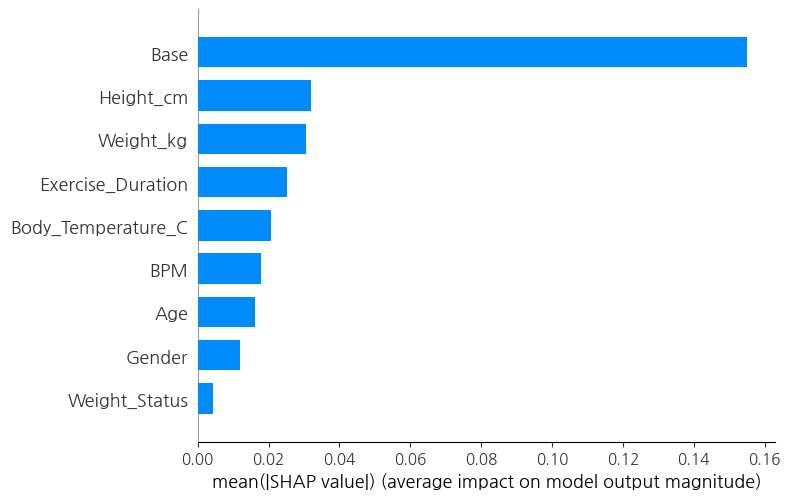


[2/2] Beeswarm (각 변수의 방향과 영향력)


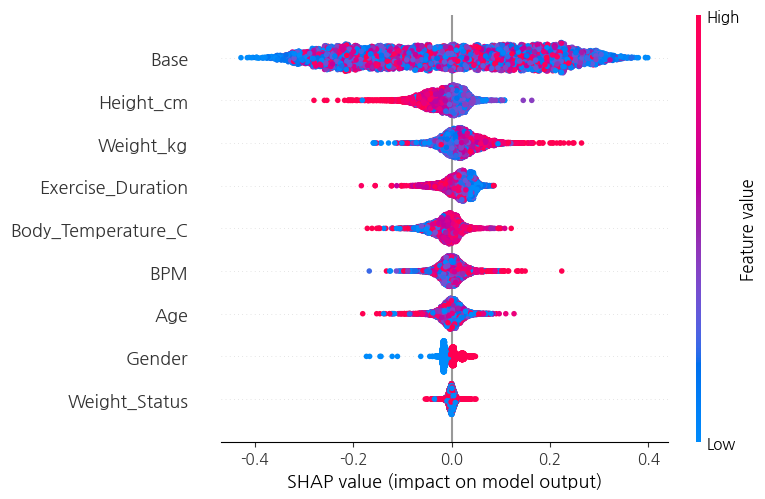


✅ SHAP 시각화 완료!
   ※ SHAP은 seed=42, fold=1 모델 기준 (예측 성능과 무관, 피처 해석용)


In [ ]:
# ============================================================
# 📊 SHAP 시각화
# ============================================================
print("\n📊 SHAP 계산 중...")

X_shap = X_gbm if WINNER == 'GBM' else X_cat

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)

# 그래프 1: 피처 중요도 막대그래프
print("\n[1/2] 피처 중요도 (막대그래프)")
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=True)

# 그래프 2: Beeswarm (방향 + 크기 동시에)
print("\n[2/2] Beeswarm (각 변수의 방향과 영향력)")
shap.summary_plot(shap_values, X_shap, show=True)

print("\n✅ SHAP 시각화 완료!")
print("   ※ SHAP은 seed=42, fold=1 모델 기준 (예측 성능과 무관, 피처 해석용)")

EDA 탐색부분은 해석은 따로 안했습니다
나중에 추가하시면 됩니다!

## 📦 STEP 0 — 라이브러리 설치 & 데이터 준비

```python
!pip install optuna catboost shap koreanize-matplotlib -q
```
실행 전에 없는 라이브러리 네 개를 설치합니다. `optuna`는 자동으로 최적 파라미터를 찾아주는 도구고, `catboost`는 머신러닝 모델 중 하나입니다. `shap`은 어떤 변수가 예측에 얼마나 영향을 줬는지 분석할 때 씁니다. `koreanize-matplotlib`은 그래프 한글 폰트를 자동으로 설정해줍니다.

---

```python
import koreanize_matplotlib  # 한글 폰트 자동 설정
import matplotlib.pyplot as plt
```
`koreanize_matplotlib`을 import하면 한글 폰트가 자동으로 적용됩니다. 별도 설치나 설정 없이 이 한 줄로 그래프 한글 깨짐 문제가 해결됩니다.

---

```python
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from numpy.linalg import lstsq
from catboost import CatBoostRegressor
import optuna, warnings, shap
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
```
필요한 도구들을 가져옵니다. `warnings.filterwarnings('ignore')`는 불필요한 경고 메시지를 숨겨서 출력을 깔끔하게 만듭니다.

---

```python
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
```
CSV 파일을 읽어서 표 형태로 불러옵니다.

---

```python
for df in [train, test]:
    df['Height_cm']          = df['Height(Feet)']*30.48 + df['Height(Remainder_Inches)']*2.54
    df['Weight_kg']          = df['Weight(lb)'] * 0.453592
    df['Body_Temperature_C'] = (df['Body_Temperature(F)'] - 32) * 5/9
    df.drop(columns=['Height(Feet)','Height(Remainder_Inches)',
                     'Weight(lb)','Body_Temperature(F)'], inplace=True)
```
원본 데이터가 피트·파운드·화씨로 되어 있어서 cm·kg·섭씨로 바꿔줍니다. `train`과 `test` 둘 다 똑같이 변환해야 해서 `for`문으로 묶었습니다. 변환 후 원본 컬럼은 `drop`으로 삭제합니다.

---

```python
y      = train['Calories_Burned'].values
X      = train.drop(columns=['Calories_Burned','ID'])
X_test = test.drop(columns=['ID'])
```
`y`는 정답(맞춰야 할 칼로리), `X`는 입력(나이·심박수·체중 등)입니다. `ID`는 그냥 번호표라서 버립니다.

---

```python
assert X.isnull().sum().sum() == 0
assert (X['Exercise_Duration'] > 0).all()
```
데이터에 빈 값이 없는지, 운동시간이 0보다 큰지 확인하는 안전장치입니다. 문제가 있으면 여기서 에러가 나고 멈춥니다.

---

## 📊 EDA — 데이터 탐색

```python
plt.style.use('ggplot')
sns.set_palette('Set2')
```
그래프 전체 스타일을 설정합니다. `ggplot`은 배경에 격자가 있는 깔끔한 스타일이고, `Set2`는 색상 팔레트입니다.

---

### 그래프 1 — 상관계수 히트맵

```python
num_cols = ['BPM', 'Exercise_Duration', 'Body_Temperature_C',
            'Weight_kg', 'Height_cm', 'Age', 'Calories_Burned']
corr = train[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax)
```
숫자형 컬럼들 사이의 상관계수를 계산해서 히트맵으로 시각화합니다. 값이 1에 가까울수록 빨강(양의 상관), -1에 가까울수록 파랑(음의 상관)으로 표시됩니다.

---

### 그래프 2 — 칼로리 분포 + 성별 비교

```python
sns.histplot(train['Calories_Burned'], bins=50, kde=True, ax=axes[0])
sns.histplot(data=train, x='Calories_Burned', hue='Gender', bins=40, ax=axes[1])
```
왼쪽은 전체 칼로리 분포입니다. `kde=True`는 분포 곡선을 히스토그램 위에 함께 그려줍니다. 오른쪽은 성별로 나눠서 비교합니다. `hue='Gender'`가 남녀를 자동으로 다른 색으로 구분해줍니다.

---

### 그래프 3 — 핵심 변수 vs 칼로리 산점도

```python
core_cols = ['Body_Temperature_C', 'BPM', 'Exercise_Duration']
for ax, col in zip(axes, core_cols):
    sns.scatterplot(data=train, x=col, y='Calories_Burned', hue='Gender', alpha=0.3, ax=ax)
```
체온, 심박수, 운동시간 세 변수를 각각 칼로리와 비교합니다. `sns.scatterplot`은 `hue='Gender'`만 넣으면 성별 구분까지 자동으로 처리해줍니다.

---

### 그래프 4 — 이상치 탐지 (박스플롯)

```python
for ax, col in zip(axes.flatten(), ['BPM','Exercise_Duration','Body_Temperature_C','Weight_kg','Height_cm','Age']):
    sns.boxplot(x='Gender', y=col, data=train, ax=ax)
```
6개 변수를 성별로 나눠서 박스플롯으로 그립니다. 박스 바깥에 점으로 찍히는 값이 이상치입니다. `axes.flatten()`은 2차원 배열인 `axes`를 1차원으로 펴서 `for`문에서 쓰기 편하게 만드는 방법입니다.

---

### 그래프 5 — Pairplot

```python
sns.pairplot(subset, hue='Gender', diag_kind='kde', corner=True)
```
여러 변수 쌍을 한 번에 산점도로 그려줍니다. `corner=True`는 대각선 아래쪽 절반만 그려서 중복을 줄여줍니다. `diag_kind='kde'`는 대각선 자리에 분포 곡선을 그립니다. 시간이 오래 걸릴 수 있습니다.

---

### 그래프 6 — 연령대별 칼로리 분포

```python
train['AgeGroup'] = pd.cut(train['Age'], bins=[0,20,30,40,50,60,100],
                           labels=['0-20','21-30','31-40','41-50','51-60','60+'])
sns.boxplot(x='AgeGroup', y='Calories_Burned', hue='Gender', data=train)
```
`pd.cut`으로 나이를 10년 단위로 묶어서 새 컬럼을 만듭니다. 연령대별로 칼로리 소모 패턴이 어떻게 다른지 한눈에 볼 수 있습니다.

---

### 그래프 7 — 3D 산점도

```python
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(train['Exercise_Duration'], train['BPM'], train['Body_Temperature_C'],
               c=train['Calories_Burned'], cmap='coolwarm', alpha=0.6)
```
운동시간, 심박수, 체온 세 변수를 3D 공간에 점으로 찍고, 점 색깔로 칼로리를 표현합니다. 세 변수가 동시에 높을수록 칼로리가 높아지는 패턴을 입체적으로 확인할 수 있습니다.


---

## 📐 피처 생성 — build_base_features 함수

```python
keytel = np.where(mask_m,
    (-55.0969 + 0.6309*BPM + 0.1988*W + 0.2017*Age) * D / 4.184,
    (-20.4022 + 0.4472*BPM - 0.1263*W + 0.074*Age)  * D / 4.184
).clip(0)
```
**Keytel 공식**입니다. 심박수·체중·나이·운동시간으로 칼로리를 계산하는 운동과학 공식인데, 남녀 근육량 차이 때문에 계수가 다릅니다. `np.where`가 남성이면 위 공식, 여성이면 아래 공식을 선택합니다. `.clip(0)`은 혹시 음수가 나오면 0으로 막아줍니다.

---

```python
bmr = np.where(mask_m,
    88.362  + 13.397*W + 4.799*H - 5.677*Age,
    447.593 +  9.247*W + 3.098*H - 4.330*Age
)
```
**Harris-Benedict 공식**입니다. 아무것도 안 해도 소모되는 기초대사량을 계산합니다.

---

```python
hr_ratio = BPM / np.maximum(220 - Age, 1)
bsa      = np.sqrt(H * W / 3600)
```
`hr_ratio`는 최대 심박수 대비 현재 심박수 비율입니다. `220 - 나이`가 최대 심박수 추정값입니다. `bsa`는 신체 표면적입니다.

---

```python
return np.column_stack([
    BPM*D, T*D, Td*D, W*D, Age*D, H*D, D, np.ones(len(df)),
    BPM*Td*D, BPM*W*D, Td*W*D, ...
])
```
변수들을 다양하게 조합해서 총 29개 열로 만듭니다. `BPM*D`는 "심박수 × 운동시간"이고, `BPM*Td*D`는 "심박수 × 체온편차 × 운동시간"처럼 여러 변수를 동시에 고려합니다. 단독보다 조합이 칼로리를 더 잘 설명하기 때문입니다.

---

## 기저 모델 학습 — base_oof / base_full

```python
c,_,_,_ = lstsq(build_base_features(tr_df[tr_m]), y[tr_idx][tr_m], rcond=None)
oof[val_idx[val_m]] = build_base_features(val_df[val_m]) @ c
```
`lstsq`는 29개 변수에 각각 얼마를 곱해야 정답과 제일 가까워지는지를 수학적으로 계산합니다. `@`는 행렬 곱셈 기호로, "계수 × 피처 = 예측값"을 한 번에 계산합니다. 성별을 `F`, `M`으로 분리해서 따로 학습하는데, 같이 학습하면 남녀 평균값으로 맞추려다가 둘 다 틀리게 되기 때문입니다.

---

## STEP 2 — 잔차 & Box-Cox

```python
residual = y - train_base
```
선형 공식이 예측한 값과 실제 칼로리의 차이가 **잔차**(오차)입니다. 이 오차를 다음 단계에서 GB 모델이 추가로 학습합니다. 선형 공식이 큰 그림을 잡으면 GB가 세밀하게 보정하는 구조입니다.

---

```python
res_bc, lambda_ = stats.boxcox(residual + res_shift)
```
잔차 분포가 한쪽으로 치우쳐 있으면 모델이 학습하기 어렵습니다. **Box-Cox 변환**으로 분포를 종 모양(정규분포)에 가깝게 펴줍니다. `lambda_`는 나중에 역변환할 때 다시 필요합니다.

---

## STEP 3 — 피처 인코딩

```python
d['Gender'] = (d['Gender'] == 'M').astype(int)
ws_map = {'Underweight':0,'Normal Weight':1,'Overweight':2,'Obese':3}
d['Weight_Status'] = d['Weight_Status'].map(ws_map)
```
GBM은 문자를 직접 계산하지 못하기 때문에 숫자로 바꿔줍니다. CatBoost는 이 처리를 내부에서 알아서 하기 때문에 문자 그대로 넣어도 됩니다.

---

```python
d['Base'] = base_pred
```
선형 공식의 예측값 자체를 새로운 피처로 추가합니다. "이미 이만큼 계산됐다"는 정보를 GB에게 알려주는 것입니다.

---

## STEP 4 — Optuna 하이퍼파라미터 탐색

```python
n_estimators  = trial.suggest_int('n_estimators', 300, 5000)
learning_rate = trial.suggest_float('learning_rate', 0.001, 0.1, log=True)
max_depth     = trial.suggest_int('max_depth', 1, 4)
```
모델 설정값(하이퍼파라미터)을 사람이 일일이 시험하는 대신 Optuna가 자동으로 찾아줍니다. 각 파라미터 역할입니다.

- `n_estimators` — 트리를 몇 개 만들지
- `learning_rate` — 한 번에 얼마나 배울지 (낮을수록 천천히, 안정적)
- `max_depth` — 트리가 얼마나 깊이 파고들지 (깊을수록 복잡해짐)
- `subsample` — 매번 데이터 몇 %만 써서 다양성 확보
- `min_samples_leaf` — 잎에 최소 몇 개 데이터가 있어야 하는지

GBM 100번, CatBoost 50번 시험해서 RMSE가 더 낮은 쪽을 자동으로 최종 모델로 선택합니다. 실행할 때마다 결과가 달라질 수 있습니다.

---

## STEP 5 — 최종 학습 (10-Fold × 10 Seeds)

```python
shap_model = None
```
루프 시작 전에 빈 변수를 하나 만들어둡니다. 나중에 여기에 SHAP용 모델을 저장합니다.

---

```python
SEEDS = [42, 777, 2024, 1234, 99, 314, 5678, 9999, 111, 2077]
for seed in SEEDS:
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_gbm)):
        ...
        pred_final += m.predict(X_te_gbm) / (len(SEEDS) * N)
```
랜덤 시드가 다르면 조금씩 다른 모델이 만들어지고, 각각 약간 다른 부분을 잘 맞춥니다. 이 100개(10 seeds × 10 folds)의 예측을 평균내면 개별 오차가 서로 상쇄돼서 훨씬 안정적인 예측이 됩니다. 이것을 **앙상블**이라고 합니다.

---

```python
if seed == 42 and fold == 0:
    shap_model = m
```
루프가 100번 돌아가는 동안 딱 한 번만 모델을 저장합니다. 100개 모델 전부 SHAP을 계산하면 시간이 너무 오래 걸리기 때문에 첫 번째 모델만 대표로 씁니다.

---

```python
final_pred = np.clip(test_base + inv_bc(pred_final, lambda_) - res_shift, 1.0, None)
```
최종 예측값은 선형 공식 예측 + GB 잔차 예측(역변환)입니다. 칼로리는 최소 1kcal 이상이어야 하니까 `.clip(1.0, None)`으로 0 이하가 나오면 막아줍니다.

---

```python
assert not np.isnan(final_pred).any()
assert not np.isinf(final_pred).any()
assert (final_pred >= 1.0).all()
pd.DataFrame({'ID': test['ID'], 'Calories_Burned': final_pred}).to_csv('submission.csv', index=False)
```
제출 전 마지막 검증입니다. NaN(결측값), Inf(무한대), 1 미만 값이 있으면 에러를 내고 멈춥니다. 다 통과하면 `submission.csv`로 저장합니다.

---

## 📊 SHAP 시각화

```python
X_shap = X_gbm if WINNER == 'GBM' else X_cat
```
SHAP에 넘길 데이터를 결정합니다. 승자 모델에 따라 GBM용 데이터를 쓸지, CatBoost용 데이터를 쓸지 자동으로 선택됩니다.

---

```python
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)
```
`TreeExplainer`는 트리 기반 모델 전용 SHAP 계산기입니다. GBM과 CatBoost 둘 다 트리 기반이라 그대로 쓸 수 있습니다. `shap_values`는 데이터 하나하나마다 "이 피처가 예측값을 얼마나 올렸는지/내렸는지"를 담은 값입니다.

---

```python
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=True)
```
**그래프 1 — 막대그래프**입니다. 막대가 길수록 해당 피처가 예측에 많이 영향을 줬다는 뜻입니다. 방향은 무시하고 순수하게 "얼마나 중요한가"만 보여줍니다.

---

```python
shap.summary_plot(shap_values, X_shap, show=True)
```
**그래프 2 — Beeswarm**입니다. 점 하나가 데이터 하나입니다.

- 빨간 점 → 해당 피처의 값이 높음
- 파란 점 → 해당 피처의 값이 낮음
- 오른쪽 → 칼로리 예측을 올리는 방향으로 기여
- 왼쪽 → 칼로리 예측을 내리는 방향으로 기여

예를 들어 심박수(BPM)에서 빨간 점이 오른쪽에 몰려 있다면 "심박수가 높을수록 칼로리 예측이 올라간다"고 해석할 수 있습니다.


## 📊 막대그래프 해석

막대가 길수록 그 변수가 예측에 많이 영향을 줬다는 뜻입니다.

---

**1위 선형공식 예측값 (Base) — 압도적 1위**

2위와 비교해도 막대 길이 차이가 훨씬 큽니다. GB 모델이 예측할 때 선형공식이 계산해준 값을 가장 중요한 기준으로 삼는다는 뜻입니다. 선형공식이 전체 칼로리의 큰 그림을 이미 잘 잡아줬기 때문에 GB는 거기서 조금씩 보정하는 역할을 하는 겁니다. 이 코드의 2단계 구조가 잘 작동하고 있다는 증거입니다.

---

**2~4위 운동시간, 체중, 키 — 비슷한 수준**

세 변수가 막대 길이가 거의 같습니다. 선형공식이 잡지 못한 패턴을 GB가 이 세 변수로 추가 보정하고 있습니다.

---

**5위 심박수 (BPM)**

운동시간·체중·키보다는 낮지만 의미 있는 수준입니다. 선형공식에서 이미 많이 처리됐지만 일부 패턴이 GB 단계에서 추가로 잡히고 있습니다.

---

**6위 체온 (Body_Temperature_C)**

막대가 짧다고 체온이 중요하지 않은 게 아닙니다. 선형공식 단계에서 체온을 `T*D`, `Td*D`, `BPM*Td*D` 형태로 이미 충분히 처리했기 때문에 GB 단계에서 추가로 잡을 게 별로 없는 겁니다. 체온은 1단계에서 RMSE를 크게 낮춘 핵심 변수입니다.

---

**7위 나이 (Age)**

나이 자체보다는 `hr_ratio = BPM / (220 - Age)` 형태로 심박수 비율 계산에 이미 녹아 들어가 있어서 GB 단계에서의 기여가 작게 나옵니다.

---

**8위 성별 (Gender) / 9위 체중 상태 (Weight_Status) — 거의 0**

두 변수 모두 막대가 거의 없습니다. 성별은 선형공식에서 남녀 분리 학습으로 이미 완전히 처리됐고, 체중 상태는 체중·키 정보가 다른 피처에 이미 충분히 담겨 있어서 GB 단계에서 추가로 기여할 정보가 없는 겁니다.

## 📊 Beeswarm 그래프 해석

**읽는 법 먼저:**
- 빨간 점 → 해당 변수의 값이 높음
- 파란 점 → 해당 변수의 값이 낮음
- 오른쪽 → 칼로리 예측을 올리는 방향
- 왼쪽 → 칼로리 예측을 내리는 방향

---

**선형공식 예측값 (Base)**

빨간 점과 파란 점이 깔끔하게 좌우로 나뉘지 않고 섞여 있습니다. 특히 빨간 점은 가운데(0 근처)에 많이 모여 있고, 파란 점은 좌우 양쪽으로 넓게 퍼져 있습니다.

처음 보면 이상하게 느껴질 수 있는데, 사실 이게 이 모델이 잘 작동하고 있다는 신호입니다. GB가 선형공식의 예측값을 단순히 "더 높이는" 역할을 하는 게 아니라, 선형공식이 틀리기 쉬운 극단적인 구간(너무 낮거나 너무 높은 예측)에서만 적극적으로 보정하고, 중간 범위는 이미 잘 맞으니 거의 건드리지 않는 구조입니다.

---

**체중 (Weight_kg)**

빨간 점(체중 높음)이 오른쪽, 파란 점(체중 낮음)이 왼쪽에 분포합니다. 체중이 많이 나갈수록 칼로리를 올리는 방향으로 보정한다는 뜻입니다.

분포가 넓게 퍼져 있는 이유는, 체중이 높아도 운동을 짧게 하면 칼로리가 낮은 경우가 섞여 있기 때문입니다. 체중 혼자가 아니라 운동시간 같은 다른 변수와 함께 작용하는 겁니다.

---

**키 (Height_cm)**

빨간 점(키 큼)이 왼쪽, 파란 점(키 작음)이 오른쪽에 보입니다. 키가 클수록 칼로리를 내리는 방향으로 보정하는데, 직관과 반대라서 이상하게 느껴질 수 있습니다.

이유는 키와 체중의 상관계수가 0.96으로 거의 같이 움직이기 때문입니다. 체중이 이미 강하게 칼로리를 설명하고 있으니, GB 입장에서 키는 체중과 겹치는 정보로 보고 오히려 반대 방향으로 조정합니다. 이것을 다중공선성 효과라고 합니다.

---

**운동시간 (Exercise_Duration)**

빨간 점과 파란 점이 섞여 있습니다. 운동시간은 선형공식에서 거의 모든 항에 곱해지는 핵심 변수라서 이미 1단계에서 충분히 처리됐습니다. GB 단계에서 추가로 잡을 패턴이 크게 남아 있지 않은 것입니다.

---

**심박수 (BPM)**

빨간 점(심박수 높음)이 오른쪽으로 쏠려 있습니다. 심박수가 높을수록 칼로리를 올리는 방향으로 보정합니다.

체중보다 분리가 덜 명확한 이유는, 선형공식에서 이미 많이 처리됐지만 일부 비선형 패턴만 GB가 추가로 잡는 것이기 때문입니다.

---

**체온 (Body_Temperature_C)**

대부분의 점이 가운데 근처에 몰려 있고 영향이 작습니다. 체온이 중요하지 않아서가 아니라, 선형공식 단계에서 이미 충분히 반영됐기 때문입니다. 체온은 1단계에서 RMSE를 크게 낮춘 핵심 변수인데, GB 단계에서 SHAP이 낮게 나오는 이유가 바로 이겁니다.

---

**나이 (Age)**

영향 방향이 뚜렷하지 않습니다. 나이가 직접적으로 칼로리를 결정하기보다는, 코드에서 `hr_ratio = BPM / (220 - Age)`처럼 심박수 비율 계산에 이미 녹아 들어가 있어서 선형공식 단계에서 간접적으로 처리됐기 때문입니다.

---

**성별 (Gender) / 체중 상태 (Weight_Status)**

점들이 거의 0 근처에 몰려 있습니다. GB 단계에서 기여를 거의 하지 않는다는 뜻입니다.

성별은 선형공식에서 남녀를 분리 학습하는 방식으로 이미 완전히 처리됐고, 체중 상태는 체중과 키 정보가 다른 피처에 충분히 담겨 있어서 GB 단계에서 추가로 잡을 정보가 없는 겁니다.

두 그래프를 종합해서 도출할 수 있는 사실들

---

**1. 역할 분담이 명확함**

선형공식이 압도적 1위라는 건, GB가 처음부터 새로운 예측을 만드는 게 아니라 선형공식이 잡지 못한 오차만 보정하는 역할을 충실히 하고 있다는 뜻입니다. 설계한 대로 모델이 정확하게 작동하고 있는 겁니다.

---

**2. 체온은 중요한 변수인데 막대그래프만 보면 오해하기 쉬움**

막대그래프에서 체온이 6위로 낮게 나오지만, 실제로는 선형공식 단계에서 RMSE를 크게 낮춘 핵심 변수입니다. SHAP은 GB 단계 기여도만 측정하기 때문에 이미 1단계에서 처리된 변수는 낮게 나올 수밖에 없습니다. 막대그래프 순위가 곧 변수의 절대적인 중요도는 아닙니다.

---

**3. 성별 분리 학습 전략이 효과적으로 작동**

성별이 8위로 거의 0에 가깝다는 건, GB 단계에서 성별로 추가 보정할 게 없다는 뜻입니다. 선형공식에서 남녀를 따로 학습하는 방식으로 성별 차이를 이미 완전히 흡수했기 때문입니다.

---

**4. 키와 체중을 동시에 쓰는 건 주의가 필요**

키가 칼로리를 내리는 방향으로 보정되는 건 직관과 반대입니다. 키와 체중의 상관계수가 0.96이라 두 변수가 거의 같은 정보를 담고 있어서 생기는 현상입니다. 다음에 모델을 개선할 때 키 대신 BMI처럼 체중과 키를 하나로 합친 변수를 쓰거나, 둘 중 하나를 제거하는 시도를 해볼 수 있습니다.

---

**5. GB가 극단값을 교정하는 역할**

Base의 Beeswarm 패턴에서 알 수 있듯이, GB는 선형공식이 중간 범위에서 낸 예측은 거의 건드리지 않고 너무 낮거나 너무 높은 극단적인 예측에서만 적극적으로 보정합니다. 선형공식이 전반적으로는 잘 맞지만 극단값에서 약간의 편향이 있다는 뜻이기도 합니다.

---

**한줄총평** : 선형공식이 큰 그림을 잘 잡고 GB가 극단값을 교정하는 2단계 구조가 설계 의도대로 정확하게 작동하고 있습니다.

##이 아래는 참고용입니다

수업 때 배운 것하고 연결해본 것입니다.

## 🔥 칼로리 소모량 예측 모델
### EDA + Gradient Boosting 앙상블 + SHAP

---

## 📚 성취도 평가 항목 × 코드 적용 현황

### ✅ 머신러닝 기초

| 항목 | 코드에서 어디에? |
|------|----------------|
| Train / Validation / Test 역할 차이 | `KFold(n_splits=10)` — train을 10등분해서 9개로 학습, 1개로 검증. `test.csv`는 최종 제출용으로만 사용 |
| 정규화와 표준화의 차이 | 직접 적용하진 않았지만 단위 변환(피트→cm, 파운드→kg)이 비슷한 역할. 변수 스케일을 맞춰주는 전처리 개념 |
| 선형회귀에서 가중치와 편향의 의미 | `lstsq` — 29개 피처에 각각 곱해지는 계수(가중치)와 `np.ones`로 넣어준 상수항(편향)을 수학적으로 계산 |
| 결측치 처리 방법 | `assert X.isnull().sum().sum() == 0` 으로 결측치 없음 확인. `fillna(1)`로 인코딩 시 혹시 모를 결측치 대비 |
| 범주형 데이터 인코딩 | One-hot 대신 Label Encoding 사용. `Gender` M→1/F→0, `Weight_Status` 0~3으로 변환. CatBoost는 내부 자체 처리 |
| 회귀모델 성능 측정 지표 | `mean_squared_error` + `np.sqrt` = RMSE. 기저 모델 0.2910 → 최종 0.2052로 개선 확인 |
| 과적합과 과소적합의 차이 | `min_samples_leaf`, `max_depth`, `subsample` 파라미터가 과적합 방지 역할. Optuna가 자동으로 최적값 탐색 |

---

### ✅ 머신러닝 심화

| 항목 | 코드에서 어디에? |
|------|----------------|
| 교차검증(Cross Validation) / K-Fold | `KFold(n_splits=10)` — 기저 모델, Optuna 튜닝, 최종 학습 세 군데 모두 적용 |
| Bagging과 Boosting의 차이 | GBM은 Boosting 계열(앞 트리 오차를 다음 트리가 보완). 10 Seeds 앙상블은 Bagging과 유사한 효과(여러 모델 평균) |
| Random Forest vs Gradient Boosting | `GradientBoostingRegressor` 직접 사용. 잔차를 순서대로 줄여나가는 Boosting 방식이 핵심 |
| 앙상블 모델 | 10 Seeds × 10 Folds = 100개 모델 예측 평균. GBM vs CatBoost 비교 후 더 좋은 쪽 선택 |
| 하이퍼파라미터 최적화가 왜 필요한지 | `n_estimators`, `learning_rate`, `max_depth` 등을 손으로 정하면 최적값 찾기 어려움. Optuna로 자동 탐색해서 RMSE 크게 낮춤 |
| Grid Search vs Random Search vs Optuna | 코드는 베이지안 최적화(Optuna) 사용. 이전 결과를 보고 더 좋은 방향을 추론하며 탐색. `gb_obj` / `cat_obj`가 objective 함수, `trial`이 매번 파라미터 조합 제안 |
| SHAP 값의 의미 / 시각화 해석 | `shap.TreeExplainer`로 각 피처가 예측값을 얼마나 올렸는지/내렸는지 계산. 막대그래프(중요도) + Beeswarm(방향) |
| Feature Engineering이 중요한 이유 | `build_base_features` 함수. `BPM*D`, `Td*W*D` 등 조합 + Keytel·Harris-Benedict 공식 피처화 → RMSE 0.62 → 0.20대로 개선 |
| Cross Validation 결과 해석 및 모델 선택 | GBM OOF RMSE 0.2227 vs CatBoost 0.2910 비교 후 GBM 최종 선택 |

---

### ❌ 이번 코드에서 다루지 않은 항목

수업에서 배웠지만 이번 문제 특성상 적용되지 않은 개념들입니다.

| 항목 | 이유 |
|------|------|
| K-Means, DBSCAN, GMM, Mean Shift | 이번 문제는 회귀(예측)라서 군집화 불필요 |
| SVM, 마진, 서포트 벡터 | 사용한 모델이 아님 |
| Confusion Matrix, Precision, Recall, F1 | 분류 문제 지표 — 회귀 문제에는 해당 없음 |
| 클래스 불균형, 층화 샘플링 | 회귀 문제라서 해당 없음 |
| Decision Boundary | 분류 문제 개념 |

---
